<a href="https://colab.research.google.com/github/dave-heslop74/EMSC2010-W8-P1/blob/main/EMSC2010_W8_P1_NB3_SOLUTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Question: In what year will the women's Olympic 100m champion finish faster than the men's Olympic 100m champion?

Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Input women's historical data where:
* ```W_year```: year of the women's Olympic final
* ```W_time```: time of the winner (in seconds)

In [2]:
W_year = np.array([1928,1932,1936,1948,1952,1956,1960,1964,1968,1972,1976,1980,1984,1988,1992,1996,2000,2004,2008,2012,2016,2020,2024])
W_time = np.array([12.2,11.9,11.5,11.9,11.5,11.5,11,11.4,11.08,11.07,11.08,11.06,10.97,10.54,10.82,10.94,10.75,10.93,10.78,10.75,10.71,10.61,10.72])

Input men's historical data where:
* ```M_year```: year of the men's Olympic final
* ```M_time```: time of the winner (in seconds)

In [3]:
M_year = np.array([1900,1904,1908,1912,1920,1924,1928,1932,1936,1948,1952,1956,1960,1964,1968,1972,1976,1980,1984,1988,1992,1996,2000,2004,2008,2012,2016,2020,2024])
M_time = np.array([11,11,10.8,10.8,10.8,10.6,10.8,10.3,10.3,10.3,10.4,10.5,10.5,10,9.95,10.14,10.06,10.25,9.99,9.92,9.96,9.84,9.87,9.85,9.69,9.63,9.81,9.8,9.79])

Visualize the historical data.

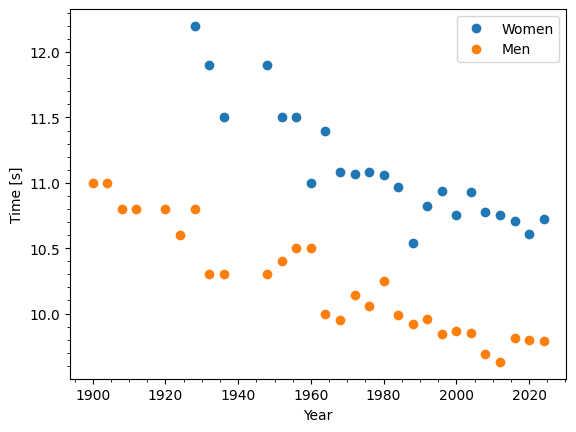

In [4]:
plt.plot(W_year,W_time,'o',label = 'Women')
plt.plot(M_year,M_time,'o',label = 'Men')
plt.xlabel('Year')
plt.ylabel('Time [s]')
plt.legend()
plt.minorticks_on()
plt.show()

To simplify the problem, you can assume that both the women's and men's times follow a straight-line with respect to year.

Importantly, we cannot predict exactly the year women will run faster than men. However, we can proceed with a more realistic question based on probabilities. For example:

*Assuming that historic trends continue into the future, when will the probability that women will run faster than men in the 100 m Olympic final exceed 50%.*

We'll start by installing ```bambi``` and importing additional packages and fitting separate straight-line models to the women's and men's data.


In [5]:
!pip install bambi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 9.1 MB/s eta 0:00:00


Import packages

In [6]:
import bambi as bmb #for automated Bayesian regression
import arviz as az #for analysis of Bayesian models
import pandas as pd #bambi requires us to work with pandas dataframes

Fit the women's data with a straight-line

In [7]:
#Fit the women's data
Wdata = pd.DataFrame({"x": W_year, "y": W_time}) #put the data into a dataframe with variable names "x" and "y".
Wmodel = bmb.Model("y ~ x", Wdata) #setup the first-order polynomial model
Widata = Wmodel.fit(draws=8000, tune=2000, chains=8) #sample the posteriors

Output()

Fit the men's data with a straight-line

In [8]:
#Fit the men's data
Mdata = pd.DataFrame({"x": M_year, "y": M_time}) #put the data into a dataframe with variable names "x" and "y".
Mmodel = bmb.Model("y ~ x", Mdata) #setup the first-order polynomial model
Midata = Mmodel.fit(draws=8000, tune=2000, chains=8) #sample the posteriors

Output()

Setup a new dataframe to make predictions for Olympic years in the future.

In [14]:
#years to predict
year_range = np.arange(1900, 2300, 4) # Predict across a Olympic years
new_data = pd.DataFrame({"x": year_range}) #dataframe with the new x-values

Sample the women's predictive posterior distribution and reshape so that each column contains the predictions for one Olympic year.


In [15]:
Wmodel.predict(Widata, data=new_data, kind='response') #predict the distribution of winning times for each year

# Make random draws from the posterior
W_pps_draws = Widata.posterior_predictive["y"].values

# Reshape to (total_draws, x_points)
W_pps_draws = W_pps_draws.reshape(-1, len(year_range))

Sample the men's predictive posterior distribution and reshape so that each column contains the predictions for one Olympic year.

In [16]:
#sample the Women's predictive posterior distribution
Mmodel.predict(Midata, data=new_data, kind='response') #predict the distribution of winning times for each year

# Make random draws from the posterior
M_pps_draws = Midata.posterior_predictive["y"].values

# Reshape to (total_draws, x_points)
M_pps_draws = M_pps_draws.reshape(-1, len(year_range))

Plot the results to visualize the prediction envelopes

/tmp/ipykernel_8027/1341826731.py:3: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  W_hdi_pps = az.hdi(W_pps_draws, hdi_prob=0.95)
/tmp/ipykernel_8027/1341826731.py:7: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  M_hdi_pps = az.hdi(M_pps_draws, hdi_prob=0.95)


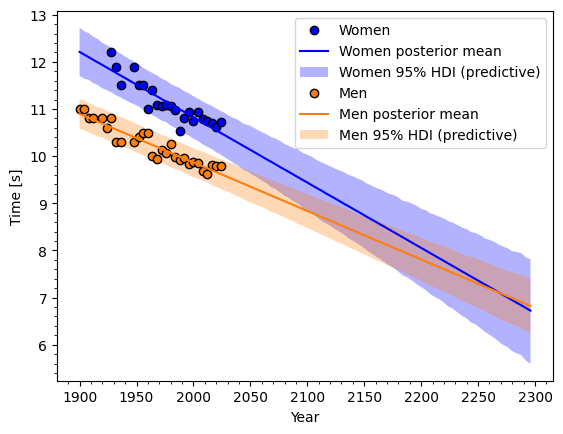

In [26]:
# Compute the HDI of the posterior predictive distributions for women
W_posterior_mean = W_pps_draws.mean(axis=0)
W_hdi_pps = az.hdi(W_pps_draws, hdi_prob=0.95)

# Compute the HDI of the posterior predictive distributions for men
M_posterior_mean = M_pps_draws.mean(axis=0)
M_hdi_pps = az.hdi(M_pps_draws, hdi_prob=0.95)

# Plot both posterior for regression lines and the observations
plt.plot(W_year, W_time, 'ok', markerfacecolor='blue', label="Women")
plt.plot(year_range, W_posterior_mean, color="blue", label="Women posterior mean")
plt.fill_between(
    year_range,
    W_hdi_pps[:, 0],
    W_hdi_pps[:, 1],
    alpha=0.3,
    color="blue",
    label="Women 95% HDI (predictive)",
    edgecolor = None
)

# Plot both posterior for regression lines and the observations
plt.plot(M_year, M_time, 'ok',markerfacecolor='C1', label="Men")
plt.plot(year_range, M_posterior_mean, color="C1", label="Men posterior mean")
plt.fill_between(
    year_range,
    M_hdi_pps[:, 0],
    M_hdi_pps[:, 1],
    alpha=0.3,
    color="C1",
    label="Men 95% HDI (predictive)",
    edgecolor = None
)

plt.xlabel('Year')
plt.ylabel('Time [s]')
plt.minorticks_on()
plt.legend()


We can now compare the women's and men's predictive posterior distributions and identify samples where the women's time is quicker than the men's time.

In [ ]:
P = W_pps_draws < M_pps_draws #find draws where the women's time is less than the men's
P = np.mean(P, axis=0) #find the probability for each year by averaging each column

Plot the result. $P$ indicates the probability that women will run faster than men in a given year.

Text(0, 0.5, 'Probability of W_time < M_time')

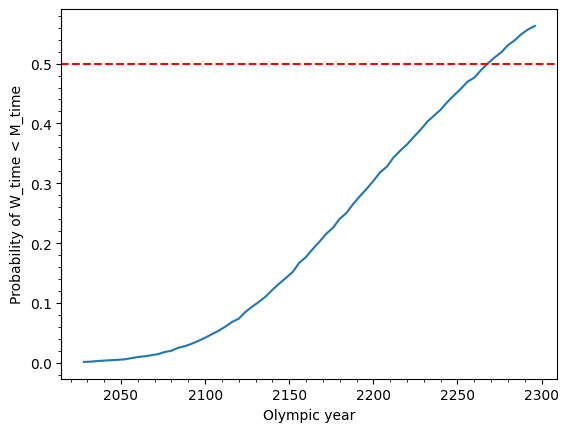

In [ ]:
plt.plot(year_range,P) #plot the resulting probability for each year
plt.gca().axhline(y=0.5, color='r', linestyle='--') #when the probability is 0.5
plt.minorticks_on() #add minorticks
plt.xlabel('Olympic year') #label the x-axis
plt.ylabel('Probability of W_time < M_time') #label the y-axis

Find the first year in which P > 0.5 and print the result on screen.

In [ ]:
result = year_range[np.argwhere(P>0.5)[0]] #find the first year when the probability exceeds 0.5
result = np.squeeze(result) #reduce to a single array
print('The first Olympic year with a probability >0.5 that the women\'s 100 m winner will run faster than the men\'s 100 m winner is {}'.format(result)) #print the result

The first Olympic year with a probability >0.5 that the women's 100 m winner will run faster than the men's 100 m winner is 2268


We have a numerical answer, but we should also consider what problems there may be with our prediction. Are there any features of our analysis that we should be worried about?